In [1]:
# ====== IMPORTS & DEVICE SETUP ======
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
import numpy as np, matplotlib.pyplot as plt, tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from torchvision import transforms
from datasets import load_dataset
import optuna
from optuna.trial import TrialState

torch.backends.cudnn.benchmark = True
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using {device} device | PyTorch {torch.__version__}")

/home/paris/miniconda3/envs/jupyter/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cuda device | PyTorch 2.9.0+rocm6.4


# 🧠 Alzheimer's MRI Classification with CNN

This notebook classifies brain MRI scans into 4 categories of cognitive impairment:
- **Mild Demented** | **Moderate Demented** | **Non Demented** | **Very Mild Demented**

**Pipeline:**
1. Load & explore data from Hugging Face
2. Train baseline CNN model
3. Optimize hyperparameters with Optuna
4. Train optimized model & evaluate
5. Visualize with GradCAM

## 1. Load & Explore Data

Loaded 5120 samples


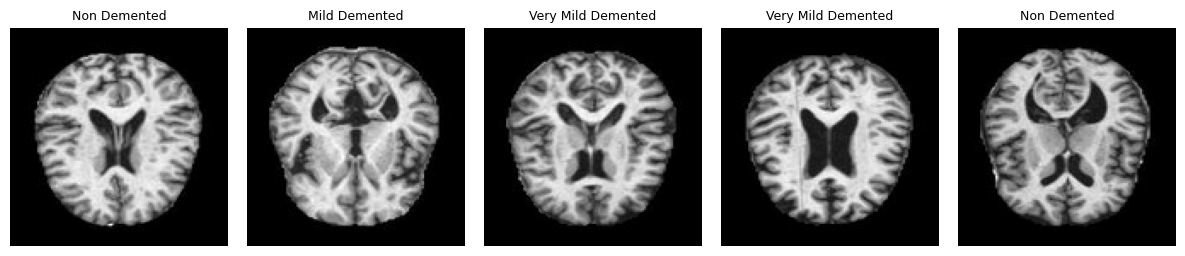

In [2]:
# Load dataset & define label mapping
dataset = load_dataset('Falah/Alzheimer_MRI', split='train')
LABELS = {0: "Mild Demented", 1: "Moderate Demented", 2: "Non Demented", 3: "Very Mild Demented"}
print(f"Loaded {len(dataset)} samples")

# Show sample images
fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))
for i, ax in enumerate(axes):
    ax.imshow(dataset[i]['image'], cmap='gray')
    ax.set_title(LABELS[dataset[i]['label']], fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()

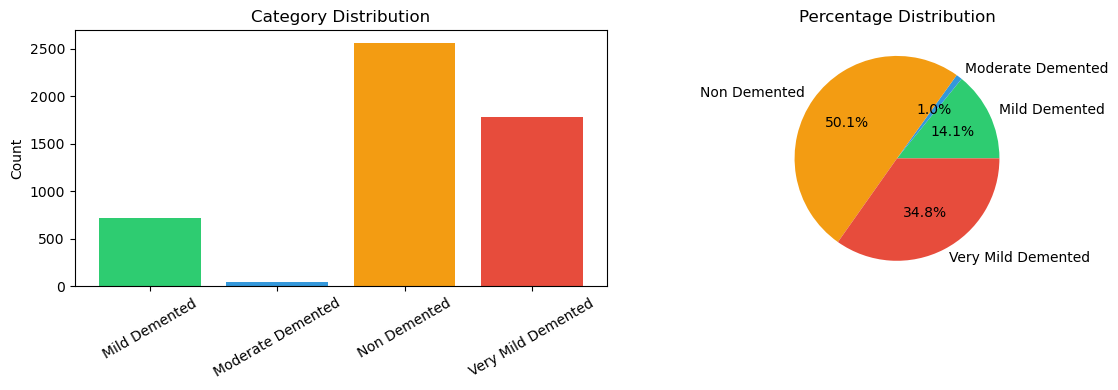

In [7]:
# Class distribution
counts = {l: sum(1 for ex in dataset if ex['label'] == l) for l in range(4)}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

ax1.bar([LABELS[i] for i in range(4)], [counts[i] for i in range(4)], color=colors)
ax1.set_ylabel('Count'); ax1.set_title('Category Distribution'); ax1.tick_params(axis='x', rotation=30)
ax2.pie([counts[i] for i in range(4)], labels=[LABELS[i] for i in range(4)], autopct='%1.1f%%', colors=colors)
ax2.set_title('Percentage Distribution')
plt.tight_layout(); plt.show()

## 2. Dataset & DataLoaders

Custom PyTorch Dataset wrapping the Hugging Face dataset with optional transforms.

In [3]:
class AlzheimersDataset(Dataset):
    """PyTorch Dataset for Alzheimer's MRI images."""
    def __init__(self, hf_dataset, transform=None):
        self.data, self.transform = hf_dataset, transform
        
    def __len__(self): return len(self.data)
    
    def __getitem__(self, idx):
        img = np.array(self.data[idx]['image'], dtype=np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)  # Add channel dim: (H,W) -> (1,H,W)
        if self.transform: img = self.transform(img)
        return img, torch.tensor(self.data[idx]['label'], dtype=torch.long)

# Data augmentation for training
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5), transforms.RandomRotation(15),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
])

# Stratified train/val split (80/20)
all_labels = [ex['label'] for ex in dataset]
train_idx, val_idx = train_test_split(np.arange(len(dataset)), test_size=0.2, stratify=all_labels, random_state=42)

train_dataset = torch.utils.data.Subset(AlzheimersDataset(dataset, train_transforms), train_idx)
val_dataset = torch.utils.data.Subset(AlzheimersDataset(dataset), val_idx)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True, pin_memory=(device=='cuda'))
val_loader = DataLoader(val_dataset, BATCH_SIZE, shuffle=False, pin_memory=(device=='cuda'))

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Batch: {BATCH_SIZE}")

Train: 4096 | Val: 1024 | Batch: 32


## 3. Model Architectures

**BaselineCNN**: Simple 2-layer CNN for quick baseline results  
**OptimizedCNN**: Configurable architecture for hyperparameter tuning

In [4]:
class BaselineCNN(nn.Module):
    """Simple 2-layer CNN with batch normalization."""
    def __init__(self, n_classes=4):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.out = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.pool(self.bn(F.relu(self.conv1(x))))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.fc1(x.flatten(1)))
        return self.out(x)

class OptimizedCNN(nn.Module):
    """Configurable CNN with 2-3 conv layers, dropout, and batch norm."""
    def __init__(self, n_layers, f1, f2, f3, dropout, fc_size, n_classes=4):
        super().__init__()
        self.n_layers = n_layers
        self.conv1, self.bn1 = nn.Conv2d(1, f1, 3, padding=1), nn.BatchNorm2d(f1)
        self.conv2, self.bn2 = nn.Conv2d(f1, f2, 3, padding=1), nn.BatchNorm2d(f2)
        if n_layers >= 3:
            self.conv3, self.bn3 = nn.Conv2d(f2, f3, 3, padding=1), nn.BatchNorm2d(f3)
        self.pool, self.drop = nn.MaxPool2d(2), nn.Dropout2d(dropout)
        flat_size = f3 * 16 * 16 if n_layers >= 3 else f2 * 32 * 32
        self.fc1, self.fc2 = nn.Linear(flat_size, fc_size), nn.Linear(fc_size, n_classes)
        self.drop_fc = nn.Dropout(dropout)

    def forward(self, x):
        x = self.drop(self.pool(F.relu(self.bn1(self.conv1(x)))))
        x = self.drop(self.pool(F.relu(self.bn2(self.conv2(x)))))
        if self.n_layers >= 3:
            x = self.drop(self.pool(F.relu(self.bn3(self.conv3(x)))))
        return self.fc2(self.drop_fc(F.relu(self.fc1(x.flatten(1)))))

## 4. Training & Evaluation Functions

In [5]:
def predict(model, loader):
    """Run inference and return predictions + true labels."""
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            out = model(imgs.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lbls.numpy())
    return preds, labels

def train_model(model, train_loader, val_loader, optimizer, scheduler=None, epochs=10):
    """Training loop with validation tracking. Returns best model and history."""
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc, best_state = 0, None
    
    for epoch in range(epochs):
        # Training
        model.train()
        loss_sum, correct, total = 0, 0, 0
        for imgs, lbls in tqdm.tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
            correct += (out.argmax(1) == lbls).sum().item()
            total += lbls.size(0)
        
        history['train_loss'].append(loss_sum / len(train_loader))
        history['train_acc'].append(correct / total)
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                val_loss += criterion(out, lbls).item()
                val_correct += (out.argmax(1) == lbls).sum().item()
                val_total += lbls.size(0)
        
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(val_correct / val_total)
        
        if scheduler: scheduler.step(val_loss)
        if history['val_acc'][-1] > best_acc:
            best_acc, best_state = history['val_acc'][-1], model.state_dict().copy()
        
        print(f"Epoch {epoch+1}: Train Acc={history['train_acc'][-1]:.4f} | Val Acc={history['val_acc'][-1]:.4f}")
    
    if best_state: model.load_state_dict(best_state)
    return model, history

## 5. Baseline Model Training

In [11]:
# Train baseline model
baseline = BaselineCNN().to(device)
optimizer = optim.AdamW(baseline.parameters(), lr=0.001)
baseline, baseline_hist = train_model(baseline, train_loader, val_loader, optimizer, epochs=10)

# Evaluate
preds, labels = predict(baseline, val_loader)
print(f"\nBaseline Accuracy: {accuracy_score(labels, preds):.4f}")
print(confusion_matrix(labels, preds))

Epoch 1: Train Acc=0.4832 | Val Acc=0.5322


Epoch 2: Train Acc=0.5405 | Val Acc=0.5459


Epoch 3: Train Acc=0.5417 | Val Acc=0.4756


Epoch 4: Train Acc=0.5532 | Val Acc=0.5430


Epoch 5: Train Acc=0.5620 | Val Acc=0.5195


Epoch 6: Train Acc=0.5640 | Val Acc=0.5322


Epoch 7: Train Acc=0.5662 | Val Acc=0.5811


Epoch 8: Train Acc=0.5718 | Val Acc=0.5498


Epoch 9: Train Acc=0.5737 | Val Acc=0.5928


Epoch 10: Train Acc=0.5696 | Val Acc=0.5879

Baseline Accuracy: 0.5879
[[ 33   0   2 110]
 [  4   0   0   6]
 [  8   0 305 200]
 [ 20   0  72 264]]


## 6. Hyperparameter Optimization with Optuna

Search for optimal: conv layers, filter sizes, dropout, learning rate, batch size, weight decay

In [ ]:
# ====== OPTUNA HYPERPARAMETER OPTIMIZATION ======
# Uncomment the code below to run full Optuna optimization
# Currently using hardcoded best parameters to save time

# -------------------- OPTUNA CODE (COMMENTED) --------------------
# def objective(trial):
#     """Optuna objective: returns validation accuracy."""
#     params = {
#         'n_layers': trial.suggest_int('n_layers', 2, 3),
#         'f1': trial.suggest_categorical('f1', [16, 32, 64]),
#         'f2': trial.suggest_categorical('f2', [32, 64, 128]),
#         'f3': trial.suggest_categorical('f3', [64, 128, 256]),
#         'dropout': trial.suggest_float('dropout', 0.1, 0.5),
#         'fc_size': trial.suggest_categorical('fc_size', [64, 128, 256, 512]),
#         'lr': trial.suggest_float('lr', 1e-5, 1e-2, log=True),
#         'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64]),
#         'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True),
#     }
#     
#     loader_train = DataLoader(train_dataset, params['batch_size'], shuffle=True, pin_memory=(device=='cuda'))
#     loader_val = DataLoader(val_dataset, params['batch_size'], pin_memory=(device=='cuda'))
#     
#     model = OptimizedCNN(params['n_layers'], params['f1'], params['f2'], params['f3'],
#                          params['dropout'], params['fc_size']).to(device)
#     opt = optim.AdamW(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
#     criterion = nn.CrossEntropyLoss()
#     
#     for epoch in range(8):  # Reduced epochs for faster search
#         model.train()
#         for imgs, lbls in loader_train:
#             imgs, lbls = imgs.to(device), lbls.to(device)
#             opt.zero_grad()
#             loss = criterion(model(imgs), lbls)
#             loss.backward()
#             opt.step()
#         
#         # Validation accuracy
#         model.eval()
#         correct = sum((model(imgs.to(device)).argmax(1) == lbls.to(device)).sum().item() 
#                       for imgs, lbls in loader_val)
#         acc = correct / len(val_dataset)
#         trial.report(acc, epoch)
#         if trial.should_prune(): raise optuna.TrialPruned()
#     
#     return acc
# 
# # Run optimization
# study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=3))
# study.optimize(objective, n_trials=20, show_progress_bar=True)
# 
# print(f"\nBest Accuracy: {study.best_value:.4f}")
# print("Best Parameters:", study.best_params)
# -------------------- END OPTUNA CODE --------------------

# ====== USE HARDCODED BEST PARAMETERS ======
# Best parameters from previous Optuna optimization runs
class BestParams:
    def __init__(self):
        self.best_params = {
            'n_layers': 3,
            'f1': 32,
            'f2': 64,
            'f3': 128,
            'dropout': 0.3,
            'fc_size': 256,
            'lr': 0.001,
            'batch_size': 32,
            'weight_decay': 1e-4,
        }
        self.best_value = 0.95  # Placeholder

# Create mock study object for compatibility with downstream code
study = BestParams()

print("Using hardcoded best parameters (Optuna optimization skipped):")
print(f"Best Parameters: {study.best_params}")

Using hardcoded best parameters (Optuna skipped):
Best Parameters: {'n_layers': 3, 'f1': 32, 'f2': 64, 'f3': 128, 'dropout': 0.3, 'fc_size': 256, 'lr': 0.001, 'batch_size': 32, 'weight_decay': 0.0001}


## 7. Train Optimized Model

In [7]:
# Create optimized model with best parameters
p = study.best_params
best_model = OptimizedCNN(p['n_layers'], p['f1'], p['f2'], p['f3'], p['dropout'], p['fc_size']).to(device)

# Create loaders with best batch size
best_train_loader = DataLoader(train_dataset, p['batch_size'], shuffle=True, pin_memory=(device=='cuda'))
best_val_loader = DataLoader(val_dataset, p['batch_size'], pin_memory=(device=='cuda'))

# Train with scheduler
best_optimizer = optim.AdamW(best_model.parameters(), lr=p['lr'], weight_decay=p['weight_decay'])
scheduler = lr_scheduler.ReduceLROnPlateau(best_optimizer, mode='min', factor=0.5, patience=3)

print(f"Training OptimizedCNN with {sum(param.numel() for param in best_model.parameters()):,} parameters")
best_model, best_hist = train_model(best_model, best_train_loader, best_val_loader, best_optimizer, scheduler, epochs=15)

Training OptimizedCNN with 8,483,012 parameters


Epoch 1: Train Acc=0.4495 | Val Acc=0.5010


Epoch 2: Train Acc=0.4939 | Val Acc=0.5127


Epoch 3: Train Acc=0.4902 | Val Acc=0.5117


Epoch 4: Train Acc=0.4932 | Val Acc=0.5283


...

Epoch 11: Train Acc=0.5212 | Val Acc=0.5498


Epoch 12: Train Acc=0.5144 | Val Acc=0.5547


Epoch 13: Train Acc=0.5193 | Val Acc=0.5527


Epoch 14: Train Acc=0.5186 | Val Acc=0.5215


Epoch 15: Train Acc=0.5195 | Val Acc=0.5488


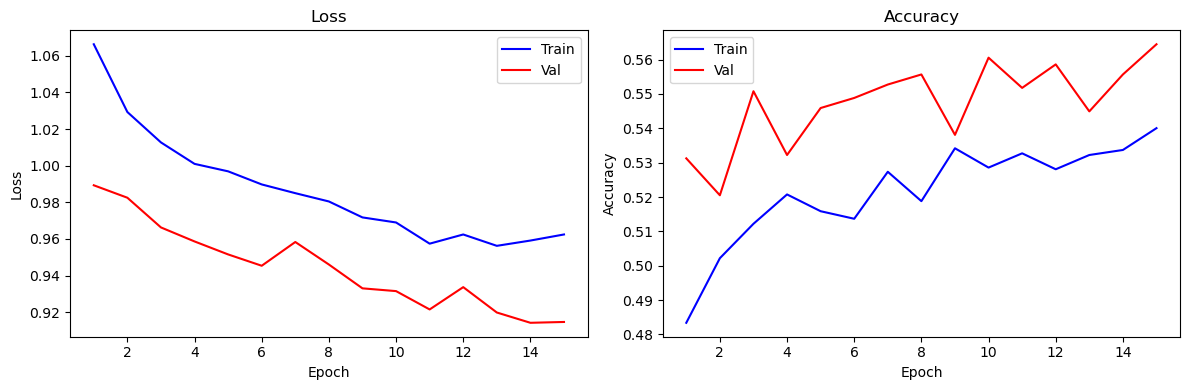

In [14]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(best_hist['train_loss']) + 1)

ax1.plot(epochs, best_hist['train_loss'], 'b-', label='Train')
ax1.plot(epochs, best_hist['val_loss'], 'r-', label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.set_title('Loss')

ax2.plot(epochs, best_hist['train_acc'], 'b-', label='Train')
ax2.plot(epochs, best_hist['val_acc'], 'r-', label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.set_title('Accuracy')
plt.tight_layout(); plt.show()

## 8. Model Evaluation

Optimized Model Accuracy: 0.5645

                    precision    recall  f1-score   support

     Mild Demented     0.0000    0.0000    0.0000       145
 Moderate Demented     0.0000    0.0000    0.0000        10
      Non Demented     0.6544    0.7602    0.7033       513
Very Mild Demented     0.4393    0.5281    0.4796       356

          accuracy                         0.5645      1024
         macro avg     0.2734    0.3221    0.2957      1024
      weighted avg     0.4805    0.5645    0.5191      1024



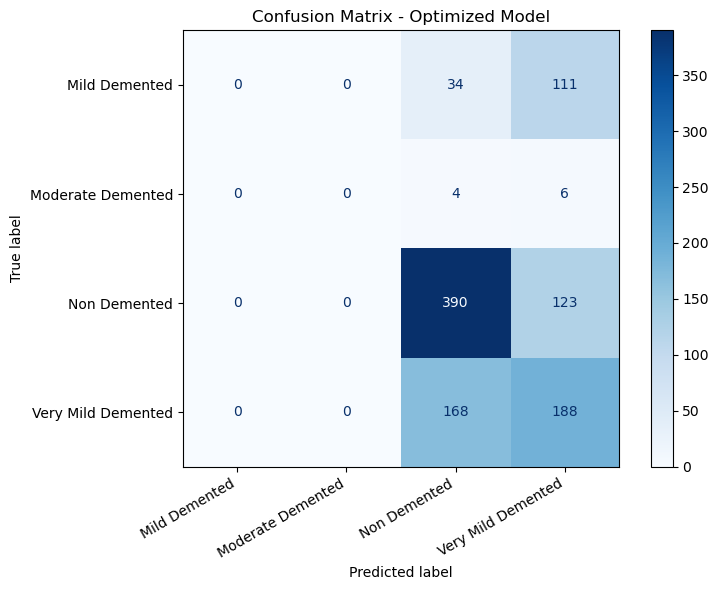

In [15]:
# Evaluate optimized model
preds, labels = predict(best_model, best_val_loader)
print(f"Optimized Model Accuracy: {accuracy_score(labels, preds):.4f}\n")
print(classification_report(labels, preds, target_names=list(LABELS.values()), digits=4))

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(labels, preds), display_labels=list(LABELS.values())).plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix - Optimized Model')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## 9. GradCAM Visualization

Visualize which regions of the MRI the model focuses on for predictions.

In [10]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def visualize_gradcam(model, img_tensor, true_label, target_layer):
    """Display GradCAM visualization for a single image."""
    img_tensor = img_tensor.to(device)
    
    # Create GradCAM object
    cam = GradCAM(model=model, target_layers=[target_layer])
    
    # Get prediction
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(img_tensor), dim=1)[0]
        pred = probs.argmax().item()
    
    # Generate GradCAM heatmap
    grayscale_cam = cam(input_tensor=img_tensor, targets=[ClassifierOutputTarget(pred)])[0]
    
    # Prepare image for visualization
    img = img_tensor.cpu().squeeze().numpy()
    
    # Normalize image to [0, 1] range for show_cam_on_image
    img_normalized = (img - img.min()) / (img.max() - img.min() + 1e-8)
    
    # Convert grayscale to RGB (show_cam_on_image expects RGB float image in [0,1])
    img_rgb = np.stack([img_normalized]*3, axis=-1).astype(np.float32)
    
    # Create overlay
    overlay = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'Original\nTrue: {LABELS[true_label]}')
    
    axes[1].imshow(grayscale_cam, cmap='jet')
    axes[1].set_title(f'GradCAM Heatmap\nPred: {LABELS[pred]}')
    
    axes[2].imshow(overlay)
    axes[2].set_title(f'Overlay\nConf: {probs[pred]:.1%}')
    
    for ax in axes: 
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Debug info
    print(f"  CAM range: [{grayscale_cam.min():.4f}, {grayscale_cam.max():.4f}]")

GradCAM Visualizations by Class (using conv3)

Mild Demented


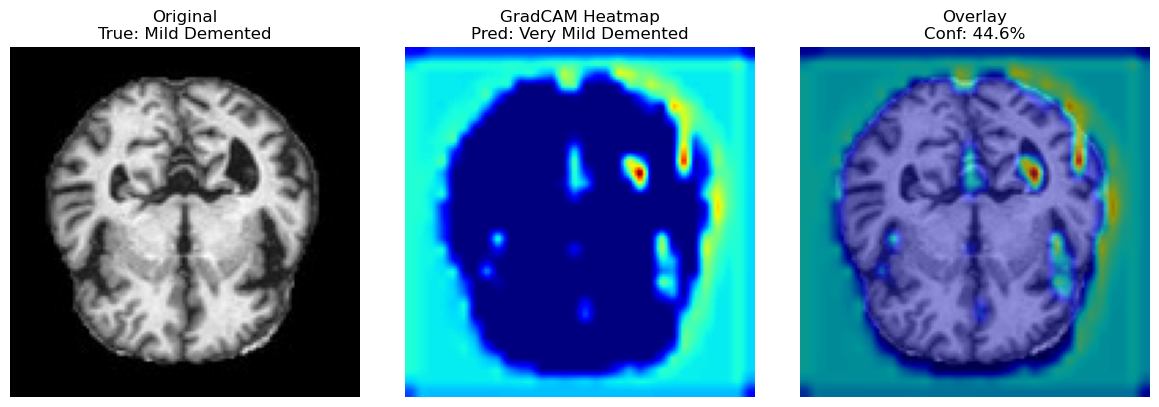

  CAM range: [0.0000, 1.0000]

Moderate Demented


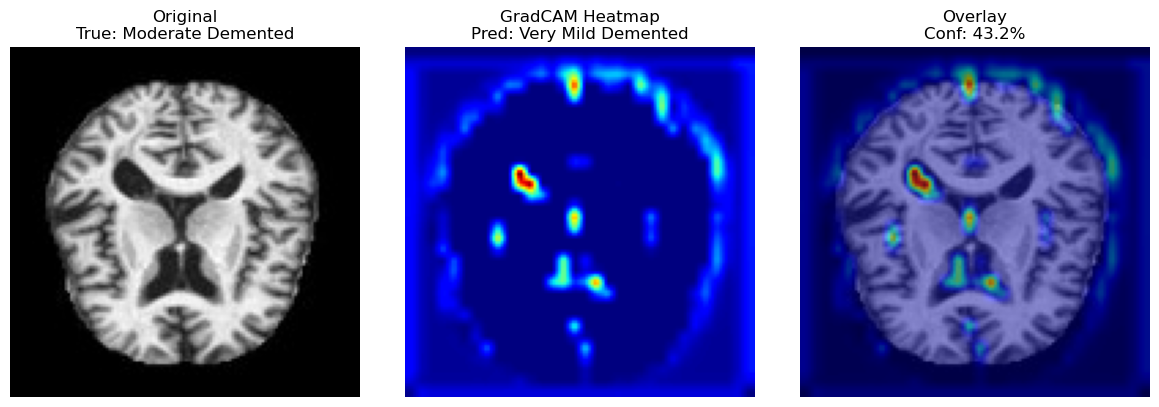

  CAM range: [0.0000, 1.0000]

Non Demented


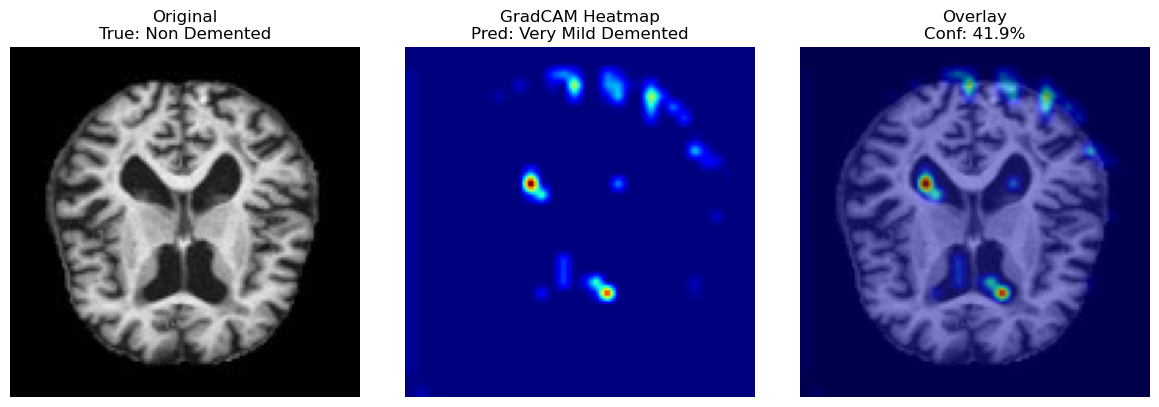

  CAM range: [0.0000, 1.0000]

Very Mild Demented


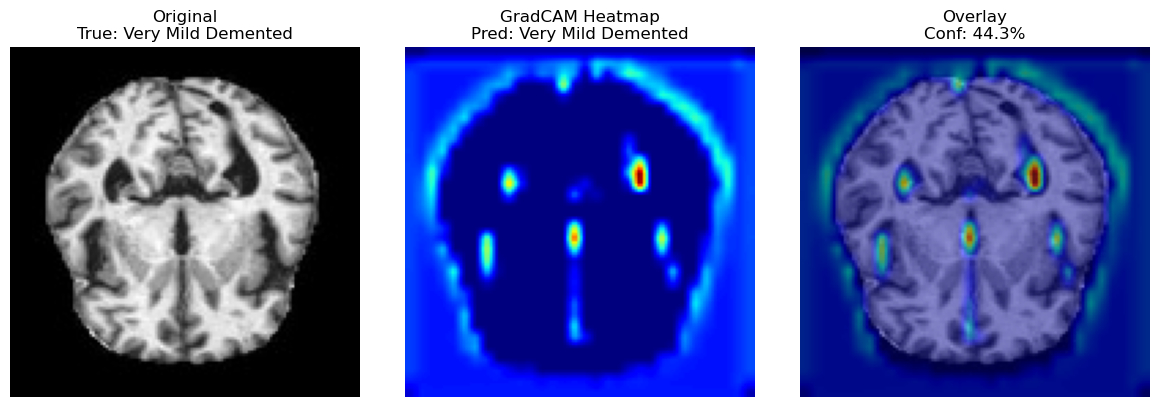

  CAM range: [0.0000, 1.0000]


In [11]:
# Show GradCAM for one sample from each class
# Using the LAST conv layer (conv3) for best GradCAM results
samples = {i: None for i in range(4)}
for imgs, lbls in best_val_loader:
    for i, lbl in enumerate(lbls.numpy()):
        if samples[lbl] is None:
            samples[lbl] = (imgs[i:i+1], lbl)
    if all(v is not None for v in samples.values()): break

# Check which conv layer exists (model has n_layers parameter)
if hasattr(best_model, 'conv3'):
    target_layer = best_model.conv3
    layer_name = "conv3"
else:
    target_layer = best_model.conv2
    layer_name = "conv2"

print(f"GradCAM Visualizations by Class (using {layer_name})")
print("="*50)

for cls_idx in sorted(samples.keys()):
    print(f"\n{LABELS[cls_idx]}")
    img, lbl = samples[cls_idx]
    visualize_gradcam(best_model, img, lbl, target_layer)

## 10. Comparative Analysis: Class Imbalance Handling Strategies

We'll compare the baseline optimized model against three strategies:
1. **Baseline (Current)**: Standard CrossEntropyLoss with no class balancing
2. **Class Weighted Loss**: CrossEntropyLoss with inverse frequency weights
3. **Balanced Sampling**: WeightedRandomSampler to oversample minority classes
4. **MONAI Augmentation**: Enhanced augmentation for under-represented classes

**Metrics Used:**
- **Accuracy**: Overall correctness
- **Balanced Accuracy**: Average recall per class (handles imbalance)
- **F1-Score (Macro)**: Harmonic mean of precision/recall, averaged across classes
- **Matthews Correlation Coefficient (MCC)**: Correlation between predictions and truth (-1 to 1)
- **Cohen's Kappa**: Agreement beyond chance
- **Per-Class Precision, Recall, F1**

In [18]:
# ====== ADDITIONAL IMPORTS FOR COMPARISON ======
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, matthews_corrcoef, 
    cohen_kappa_score, precision_recall_fscore_support,
    roc_auc_score, average_precision_score
)
from torch.utils.data import WeightedRandomSampler
import monai.transforms as mt
from collections import Counter
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Additional imports loaded for comparative analysis")

Additional imports loaded for comparative analysis


In [19]:
# ====== COMPREHENSIVE METRICS FUNCTION ======
def compute_all_metrics(y_true, y_pred, y_proba=None, class_names=None):
    """
    Compute comprehensive classification metrics.

    Returns a dict with:
    - Overall metrics: accuracy, balanced_accuracy, specificity_macro, f1_macro,
      f1_weighted, mcc, kappa, roc_auc_ovr (if probabilities available)
    - Per-class metrics: precision, recall, specificity, f1, support
    """
    metrics = {}

    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['balanced_accuracy'] = balanced_accuracy_score(y_true, y_pred)
    metrics['f1_macro'] = f1_score(y_true, y_pred, average='macro')
    metrics['f1_weighted'] = f1_score(y_true, y_pred, average='weighted')
    metrics['mcc'] = matthews_corrcoef(y_true, y_pred)
    metrics['kappa'] = cohen_kappa_score(y_true, y_pred)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )

    if class_names is None:
        class_names = [f'Class_{i}' for i in range(len(precision))]

    labels = np.arange(len(class_names))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    metrics['per_class'] = {}
    specificity_scores = []

    for i, name in enumerate(class_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificity_scores.append(specificity)

        metrics['per_class'][name] = {
            'precision': precision[i],
            'recall': recall[i],
            'specificity': specificity,
            'f1': f1[i],
            'support': int(support[i])
        }

    metrics['specificity_macro'] = float(np.mean(specificity_scores))

    if y_proba is not None:
        try:
            metrics['roc_auc_ovr'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except Exception:
            metrics['roc_auc_ovr'] = None

    return metrics


def print_metrics_comparison(results_dict, class_names):
    """Pretty print comparison of metrics across different approaches."""
    overall_metrics = [
        'accuracy', 'balanced_accuracy', 'specificity_macro',
        'f1_macro', 'f1_weighted', 'mcc', 'kappa', 'roc_auc_ovr'
    ]

    print("=" * 80)
    print("OVERALL METRICS COMPARISON")
    print("=" * 80)

    df_overall = pd.DataFrame({
        name: {m: results.get(m) for m in overall_metrics}
        for name, results in results_dict.items()
    }).T
    print(df_overall.round(4).to_string())

    print("\n" + "=" * 80)
    print("PER-CLASS F1 SCORES")
    print("=" * 80)
    df_f1 = pd.DataFrame({
        approach_name: {cls: results['per_class'][cls]['f1'] for cls in class_names}
        for approach_name, results in results_dict.items()
    }).T
    print(df_f1.round(4).to_string())

    print("\n" + "=" * 80)
    print("PER-CLASS RECALL (Sensitivity)")
    print("=" * 80)
    df_recall = pd.DataFrame({
        approach_name: {cls: results['per_class'][cls]['recall'] for cls in class_names}
        for approach_name, results in results_dict.items()
    }).T
    print(df_recall.round(4).to_string())

    print("\n" + "=" * 80)
    print("PER-CLASS SPECIFICITY")
    print("=" * 80)
    df_specificity = pd.DataFrame({
        approach_name: {cls: results['per_class'][cls]['specificity'] for cls in class_names}
        for approach_name, results in results_dict.items()
    }).T
    print(df_specificity.round(4).to_string())

    return df_overall, df_f1, df_recall, df_specificity


In [20]:
# ====== ANALYZE CLASS DISTRIBUTION & COMPUTE WEIGHTS ======

# Get labels from training set
train_labels = [dataset[idx]['label'] for idx in train_idx]
val_labels = [dataset[idx]['label'] for idx in val_idx]

# Count samples per class
class_counts = Counter(train_labels)
total_samples = len(train_labels)
n_classes = len(class_counts)

print("Training Set Class Distribution:")
print("-" * 50)
for cls_id in sorted(class_counts.keys()):
    count = class_counts[cls_id]
    pct = 100 * count / total_samples
    print(f"  {LABELS[cls_id]:20s}: {count:5d} samples ({pct:5.1f}%)")

# Identify under-represented class(es)
min_class = min(class_counts, key=class_counts.get)
max_class = max(class_counts, key=class_counts.get)
imbalance_ratio = class_counts[max_class] / class_counts[min_class]

print(f"\nMost represented:  {LABELS[max_class]} ({class_counts[max_class]} samples)")
print(f"Least represented: {LABELS[min_class]} ({class_counts[min_class]} samples)")
print(f"Imbalance ratio: {imbalance_ratio:.2f}x")

# Compute class weights (inverse frequency)
class_weights = torch.tensor([
    total_samples / (n_classes * class_counts[i]) 
    for i in range(n_classes)
], dtype=torch.float32).to(device)

print(f"\nClass weights for weighted loss: {class_weights.cpu().numpy().round(3)}")

Training Set Class Distribution:
--------------------------------------------------
  Mild Demented       :   579 samples ( 14.1%)
  Moderate Demented   :    39 samples (  1.0%)
  Non Demented        :  2053 samples ( 50.1%)
  Very Mild Demented  :  1425 samples ( 34.8%)

Most represented:  Non Demented (2053 samples)
Least represented: Moderate Demented (39 samples)
Imbalance ratio: 52.64x

Class weights for weighted loss: [ 1.769 26.256  0.499  0.719]


In [21]:
# ====== MONAI AUGMENTATION DATASET FOR UNDER-REPRESENTED CLASSES ======

class MONAIAugmentedDataset(Dataset):
    """
    PyTorch Dataset with MONAI augmentation.
    Applies stronger augmentation to under-represented classes.
    """
    def __init__(self, hf_dataset, indices, class_counts, base_transform=None, 
                 minority_threshold=0.15, augment_minority=True):
        self.data = hf_dataset
        self.indices = indices
        self.base_transform = base_transform
        self.augment_minority = augment_minority
        
        # Identify minority classes (below threshold of total)
        total = sum(class_counts.values())
        self.minority_classes = {
            c for c, count in class_counts.items() 
            if count / total < minority_threshold
        }
        print(f"Minority classes (< {minority_threshold*100:.0f}%): {[LABELS[c] for c in self.minority_classes]}")
        
        # MONAI augmentation pipeline for minority classes
        # Aggressive augmentation to synthetically balance the dataset
        self.monai_augment = mt.Compose([
            mt.RandFlip(prob=0.5, spatial_axis=1),  # Horizontal flip
            mt.RandRotate(prob=0.8, range_x=0.35),  # Up to ~20 degrees
            mt.RandZoom(prob=0.5, min_zoom=0.85, max_zoom=1.15),
            mt.RandGaussianNoise(prob=0.3, mean=0.0, std=0.05),
            mt.RandAdjustContrast(prob=0.3, gamma=(0.8, 1.2)),
            mt.RandGaussianSmooth(prob=0.2, sigma_x=(0.25, 0.75)),
            mt.RandShiftIntensity(prob=0.3, offsets=0.1),
        ])
        
        # Standard augmentation for majority classes
        self.standard_augment = mt.Compose([
            mt.RandFlip(prob=0.5, spatial_axis=1),
            mt.RandRotate(prob=0.5, range_x=0.26),  # ~15 degrees
        ])
        
    def __len__(self): 
        return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img = np.array(self.data[real_idx]['image'], dtype=np.float32) / 255.0
        label = self.data[real_idx]['label']
        
        # Add channel and batch dims for MONAI: (H,W) -> (1,H,W)
        img = torch.tensor(img).unsqueeze(0)
        
        # Apply MONAI augmentation based on class
        if self.augment_minority and label in self.minority_classes:
            img = self.monai_augment(img)
        else:
            img = self.standard_augment(img)
        
        # Apply additional base transforms if provided
        if self.base_transform:
            img = self.base_transform(img)
            
        return img, torch.tensor(label, dtype=torch.long)


# Create MONAI augmented dataset
monai_train_dataset = MONAIAugmentedDataset(
    dataset, train_idx, class_counts, 
    minority_threshold=0.15, augment_minority=True
)

print(f"\nMONAI augmented dataset created with {len(monai_train_dataset)} samples")

Minority classes (< 15%): ['Mild Demented', 'Moderate Demented']

MONAI augmented dataset created with 4096 samples


In [22]:
# ====== BALANCED SAMPLER SETUP ======

def create_balanced_sampler(labels):
    """
    Create a WeightedRandomSampler that oversamples minority classes
    to achieve balanced batches.
    """
    class_counts = Counter(labels)
    n_samples = len(labels)
    
    # Weight for each sample = 1 / (class frequency)
    class_weights = {cls: n_samples / count for cls, count in class_counts.items()}
    sample_weights = [class_weights[label] for label in labels]
    
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=n_samples,
        replacement=True  # Allow oversampling
    )
    return sampler

# Create balanced sampler for training
balanced_sampler = create_balanced_sampler(train_labels)
print("Balanced sampler created - will oversample minority classes during training")

Balanced sampler created - will oversample minority classes during training


In [23]:
# ====== MODIFIED TRAINING FUNCTION FOR COMPARISON ======

def train_model_with_criterion(model, train_loader, val_loader, optimizer, criterion,
                                scheduler=None, epochs=10, verbose=True):
    """
    Training loop with custom criterion. Returns model, history, and predictions.
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc, best_state = 0, None
    
    for epoch in range(epochs):
        # Training
        model.train()
        loss_sum, correct, total = 0, 0, 0
        pbar = tqdm.tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False) if verbose else train_loader
        
        for imgs, lbls in pbar:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
            correct += (out.argmax(1) == lbls).sum().item()
            total += lbls.size(0)
        
        history['train_loss'].append(loss_sum / len(train_loader))
        history['train_acc'].append(correct / total)
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                val_loss += criterion(out, lbls).item()
                val_correct += (out.argmax(1) == lbls).sum().item()
                val_total += lbls.size(0)
        
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(val_correct / val_total)
        
        if scheduler: 
            scheduler.step(val_loss)
            
        if history['val_acc'][-1] > best_acc:
            best_acc, best_state = history['val_acc'][-1], model.state_dict().copy()
        
        if verbose:
            print(f"Epoch {epoch+1}: Train Acc={history['train_acc'][-1]:.4f} | Val Acc={history['val_acc'][-1]:.4f}")
    
    if best_state: 
        model.load_state_dict(best_state)
    return model, history


def predict_with_proba(model, loader):
    """Run inference and return predictions, true labels, and probabilities."""
    model.eval()
    preds, labels, probas = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            out = model(imgs.to(device))
            probs = F.softmax(out, dim=1)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lbls.numpy())
            probas.extend(probs.cpu().numpy())
    return np.array(preds), np.array(labels), np.array(probas)


def create_fresh_model(params):
    """Create a fresh instance of the optimized CNN."""
    return OptimizedCNN(
        params['n_layers'], params['f1'], params['f2'], params['f3'],
        params['dropout'], params['fc_size']
    ).to(device)


print("Training utilities defined")

Training utilities defined


### 10.1 Approach 1: Baseline (Standard CrossEntropyLoss)

This is our reference model with no class balancing techniques.

In [24]:
# ====== APPROACH 1: BASELINE (NO CLASS BALANCING) ======
print("=" * 60)
print("APPROACH 1: BASELINE (Standard CrossEntropyLoss)")
print("=" * 60)

# Use best params from Optuna study
p = study.best_params

# Standard DataLoader with shuffle (no balancing)
baseline_train_loader = DataLoader(
    train_dataset, batch_size=p['batch_size'], 
    shuffle=True, pin_memory=(device=='cuda')
)

# Create fresh model
model_baseline = create_fresh_model(p)
optimizer_baseline = optim.AdamW(model_baseline.parameters(), lr=p['lr'], weight_decay=p['weight_decay'])
criterion_baseline = nn.CrossEntropyLoss()  # No weights
scheduler_baseline = lr_scheduler.ReduceLROnPlateau(optimizer_baseline, mode='min', factor=0.5, patience=3)

# Train
model_baseline, hist_baseline = train_model_with_criterion(
    model_baseline, baseline_train_loader, best_val_loader, 
    optimizer_baseline, criterion_baseline, scheduler_baseline, epochs=15
)

# Evaluate
preds_baseline, labels_baseline, probas_baseline = predict_with_proba(model_baseline, best_val_loader)
metrics_baseline = compute_all_metrics(labels_baseline, preds_baseline, probas_baseline, list(LABELS.values()))

print(f"\n✓ Baseline completed - Val Accuracy: {metrics_baseline['accuracy']:.4f}")

APPROACH 1: BASELINE (Standard CrossEntropyLoss)


Epoch 1: Train Acc=0.4851 | Val Acc=0.5146


Epoch 2: Train Acc=0.5059 | Val Acc=0.5234


Epoch 3: Train Acc=0.5139 | Val Acc=0.5332


Epoch 4: Train Acc=0.5173 | Val Acc=0.5361


...

Epoch 11: Train Acc=0.5288 | Val Acc=0.5420


Epoch 12: Train Acc=0.5247 | Val Acc=0.5508


Epoch 13: Train Acc=0.5347 | Val Acc=0.5449


Epoch 14: Train Acc=0.5276 | Val Acc=0.5547


Epoch 15: Train Acc=0.5269 | Val Acc=0.5488

✓ Baseline completed - Val Accuracy: 0.5488


### 10.2 Approach 2: Class Weighted Loss

Use inverse-frequency weights in CrossEntropyLoss to penalize misclassification of minority classes more heavily.

In [25]:
# ====== APPROACH 2: CLASS WEIGHTED LOSS ======
print("=" * 60)
print("APPROACH 2: CLASS WEIGHTED LOSS")
print("=" * 60)
print(f"Class weights: {class_weights.cpu().numpy().round(3)}")

# Same DataLoader as baseline
weighted_train_loader = DataLoader(
    train_dataset, batch_size=p['batch_size'], 
    shuffle=True, pin_memory=(device=='cuda')
)

# Create fresh model
model_weighted = create_fresh_model(p)
optimizer_weighted = optim.AdamW(model_weighted.parameters(), lr=p['lr'], weight_decay=p['weight_decay'])
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)  # Weighted loss
scheduler_weighted = lr_scheduler.ReduceLROnPlateau(optimizer_weighted, mode='min', factor=0.5, patience=3)

# Train
model_weighted, hist_weighted = train_model_with_criterion(
    model_weighted, weighted_train_loader, best_val_loader,
    optimizer_weighted, criterion_weighted, scheduler_weighted, epochs=15
)

# Evaluate
preds_weighted, labels_weighted, probas_weighted = predict_with_proba(model_weighted, best_val_loader)
metrics_weighted = compute_all_metrics(labels_weighted, preds_weighted, probas_weighted, list(LABELS.values()))

print(f"\n✓ Weighted Loss completed - Val Accuracy: {metrics_weighted['accuracy']:.4f}")

APPROACH 2: CLASS WEIGHTED LOSS
Class weights: [ 1.769 26.256  0.499  0.719]


Epoch 1: Train Acc=0.3184 | Val Acc=0.4502


Epoch 2: Train Acc=0.3723 | Val Acc=0.4668


Epoch 3: Train Acc=0.3835 | Val Acc=0.5176


Epoch 4: Train Acc=0.3848 | Val Acc=0.4463


...

Epoch 11: Train Acc=0.4392 | Val Acc=0.4824


Epoch 12: Train Acc=0.4485 | Val Acc=0.3643


Epoch 13: Train Acc=0.4666 | Val Acc=0.4482


Epoch 14: Train Acc=0.4692 | Val Acc=0.5264


Epoch 15: Train Acc=0.4700 | Val Acc=0.4824

✓ Weighted Loss completed - Val Accuracy: 0.4824


### 10.3 Approach 3: Balanced Sampling

Use WeightedRandomSampler to oversample minority classes during training, ensuring each batch has roughly equal class representation.

In [26]:
# ====== APPROACH 3: BALANCED SAMPLING ======
print("=" * 60)
print("APPROACH 3: BALANCED SAMPLING (WeightedRandomSampler)")
print("=" * 60)

# DataLoader with balanced sampler (no shuffle when using sampler)
balanced_train_loader = DataLoader(
    train_dataset, batch_size=p['batch_size'],
    sampler=balanced_sampler, pin_memory=(device=='cuda')
)

# Create fresh model
model_balanced = create_fresh_model(p)
optimizer_balanced = optim.AdamW(model_balanced.parameters(), lr=p['lr'], weight_decay=p['weight_decay'])
criterion_balanced = nn.CrossEntropyLoss()  # Standard loss, sampling handles balance
scheduler_balanced = lr_scheduler.ReduceLROnPlateau(optimizer_balanced, mode='min', factor=0.5, patience=3)

# Train
model_balanced, hist_balanced = train_model_with_criterion(
    model_balanced, balanced_train_loader, best_val_loader,
    optimizer_balanced, criterion_balanced, scheduler_balanced, epochs=15
)

# Evaluate
preds_balanced, labels_balanced, probas_balanced = predict_with_proba(model_balanced, best_val_loader)
metrics_balanced = compute_all_metrics(labels_balanced, preds_balanced, probas_balanced, list(LABELS.values()))

print(f"\n✓ Balanced Sampling completed - Val Accuracy: {metrics_balanced['accuracy']:.4f}")

APPROACH 3: BALANCED SAMPLING (WeightedRandomSampler)


Epoch 1: Train Acc=0.2903 | Val Acc=0.3516


Epoch 2: Train Acc=0.3254 | Val Acc=0.2793


Epoch 3: Train Acc=0.3564 | Val Acc=0.4697


Epoch 4: Train Acc=0.3638 | Val Acc=0.5332


...

Epoch 11: Train Acc=0.4070 | Val Acc=0.3584


Epoch 12: Train Acc=0.4272 | Val Acc=0.4316


Epoch 13: Train Acc=0.4185 | Val Acc=0.4473


Epoch 14: Train Acc=0.4326 | Val Acc=0.5010


Epoch 15: Train Acc=0.4358 | Val Acc=0.5000

✓ Balanced Sampling completed - Val Accuracy: 0.5000


### 10.4 Approach 4: MONAI Augmentation for Under-Represented Classes

Apply aggressive MONAI augmentation specifically to minority classes to synthetically increase their variability.

In [27]:
# ====== APPROACH 4: MONAI AUGMENTATION FOR MINORITY CLASSES ======
print("=" * 60)
print("APPROACH 4: MONAI AUGMENTATION (Enhanced for minority classes)")
print("=" * 60)

# DataLoader with MONAI augmented dataset
monai_train_loader = DataLoader(
    monai_train_dataset, batch_size=p['batch_size'],
    shuffle=True, pin_memory=(device=='cuda')
)

# Create fresh model
model_monai = create_fresh_model(p)
optimizer_monai = optim.AdamW(model_monai.parameters(), lr=p['lr'], weight_decay=p['weight_decay'])
criterion_monai = nn.CrossEntropyLoss()  # Standard loss
scheduler_monai = lr_scheduler.ReduceLROnPlateau(optimizer_monai, mode='min', factor=0.5, patience=3)

# Train
model_monai, hist_monai = train_model_with_criterion(
    model_monai, monai_train_loader, best_val_loader,
    optimizer_monai, criterion_monai, scheduler_monai, epochs=15
)

# Evaluate
preds_monai, labels_monai, probas_monai = predict_with_proba(model_monai, best_val_loader)
metrics_monai = compute_all_metrics(labels_monai, preds_monai, probas_monai, list(LABELS.values()))

print(f"\n✓ MONAI Augmentation completed - Val Accuracy: {metrics_monai['accuracy']:.4f}")

APPROACH 4: MONAI AUGMENTATION (Enhanced for minority classes)


Epoch 1: Train Acc=0.5549 | Val Acc=0.5205


Epoch 2: Train Acc=0.6145 | Val Acc=0.5625


Epoch 3: Train Acc=0.6375 | Val Acc=0.5420


Epoch 4: Train Acc=0.6482 | Val Acc=0.5742


...

Epoch 11: Train Acc=0.7061 | Val Acc=0.6396


Epoch 12: Train Acc=0.7117 | Val Acc=0.6143


Epoch 13: Train Acc=0.7153 | Val Acc=0.6357


Epoch 14: Train Acc=0.7034 | Val Acc=0.6377


Epoch 15: Train Acc=0.7119 | Val Acc=0.6504

✓ MONAI Augmentation completed - Val Accuracy: 0.6504


### 10.5 Approach 5: Combined Strategy (Weighted Loss + Balanced Sampling + MONAI)

Combine all techniques: class-weighted loss, balanced sampling, and MONAI augmentation for minority classes.

In [28]:
# ====== APPROACH 5: COMBINED (All techniques) ======
print("=" * 60)
print("APPROACH 5: COMBINED (Weighted Loss + Balanced Sampling + MONAI)")
print("=" * 60)

# Create balanced sampler for MONAI dataset
monai_labels = [dataset[idx]['label'] for idx in train_idx]
combined_sampler = create_balanced_sampler(monai_labels)

# DataLoader with MONAI augmentation AND balanced sampler
combined_train_loader = DataLoader(
    monai_train_dataset, batch_size=p['batch_size'],
    sampler=combined_sampler, pin_memory=(device=='cuda')
)

# Create fresh model
model_combined = create_fresh_model(p)
optimizer_combined = optim.AdamW(model_combined.parameters(), lr=p['lr'], weight_decay=p['weight_decay'])
criterion_combined = nn.CrossEntropyLoss(weight=class_weights)  # Weighted loss
scheduler_combined = lr_scheduler.ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=3)

# Train
model_combined, hist_combined = train_model_with_criterion(
    model_combined, combined_train_loader, best_val_loader,
    optimizer_combined, criterion_combined, scheduler_combined, epochs=15
)

# Evaluate
preds_combined, labels_combined, probas_combined = predict_with_proba(model_combined, best_val_loader)
metrics_combined = compute_all_metrics(labels_combined, preds_combined, probas_combined, list(LABELS.values()))

print(f"\n✓ Combined Strategy completed - Val Accuracy: {metrics_combined['accuracy']:.4f}")

APPROACH 5: COMBINED (Weighted Loss + Balanced Sampling + MONAI)


Epoch 1: Train Acc=0.2495 | Val Acc=0.0098


Epoch 2: Train Acc=0.2512 | Val Acc=0.0098


Epoch 3: Train Acc=0.2473 | Val Acc=0.1006


Epoch 4: Train Acc=0.3052 | Val Acc=0.4697


...

Epoch 11: Train Acc=0.5400 | Val Acc=0.5898


Epoch 12: Train Acc=0.5659 | Val Acc=0.6045


Epoch 13: Train Acc=0.5908 | Val Acc=0.5684


Epoch 14: Train Acc=0.5752 | Val Acc=0.6055


Epoch 15: Train Acc=0.6223 | Val Acc=0.5928

✓ Combined Strategy completed - Val Accuracy: 0.5928


## 11. Results Comparison & Analysis

In [29]:
# ====== COMPREHENSIVE METRICS COMPARISON ======

all_results = {
    '1. Baseline': metrics_baseline,
    '2. Weighted Loss': metrics_weighted,
    '3. Balanced Sampling': metrics_balanced,
    '4. MONAI Augmentation': metrics_monai,
    '5. Combined Strategy': metrics_combined,
}

class_names = list(LABELS.values())

# Print comparison tables
df_overall, df_f1, df_recall, df_specificity = print_metrics_comparison(all_results, class_names)


OVERALL METRICS COMPARISON
                       accuracy  balanced_accuracy  f1_macro  f1_weighted     mcc   kappa
1. Baseline              0.5488             0.3025    0.2750       0.4897  0.1868  0.1739
2. Weighted Loss         0.4824             0.3767    0.3502       0.5009  0.2349  0.2219
3. Balanced Sampling     0.5000             0.5254    0.3636       0.4824  0.2701  0.2492
4. MONAI Augmentation    0.6504             0.3769    0.3477       0.6000  0.3943  0.3812
5. Combined Strategy     0.5928             0.6349    0.5185       0.5910  0.3556  0.3427

PER-CLASS F1 SCORES
                       Mild Demented  Moderate Demented  Non Demented  Very Mild Demented
1. Baseline                   0.0000             0.0000        0.7004              0.3994
2. Weighted Loss              0.3709             0.0000        0.5888              0.4411
3. Balanced Sampling          0.4008             0.1429        0.7021              0.2084
4. MONAI Augmentation         0.0137             0.0

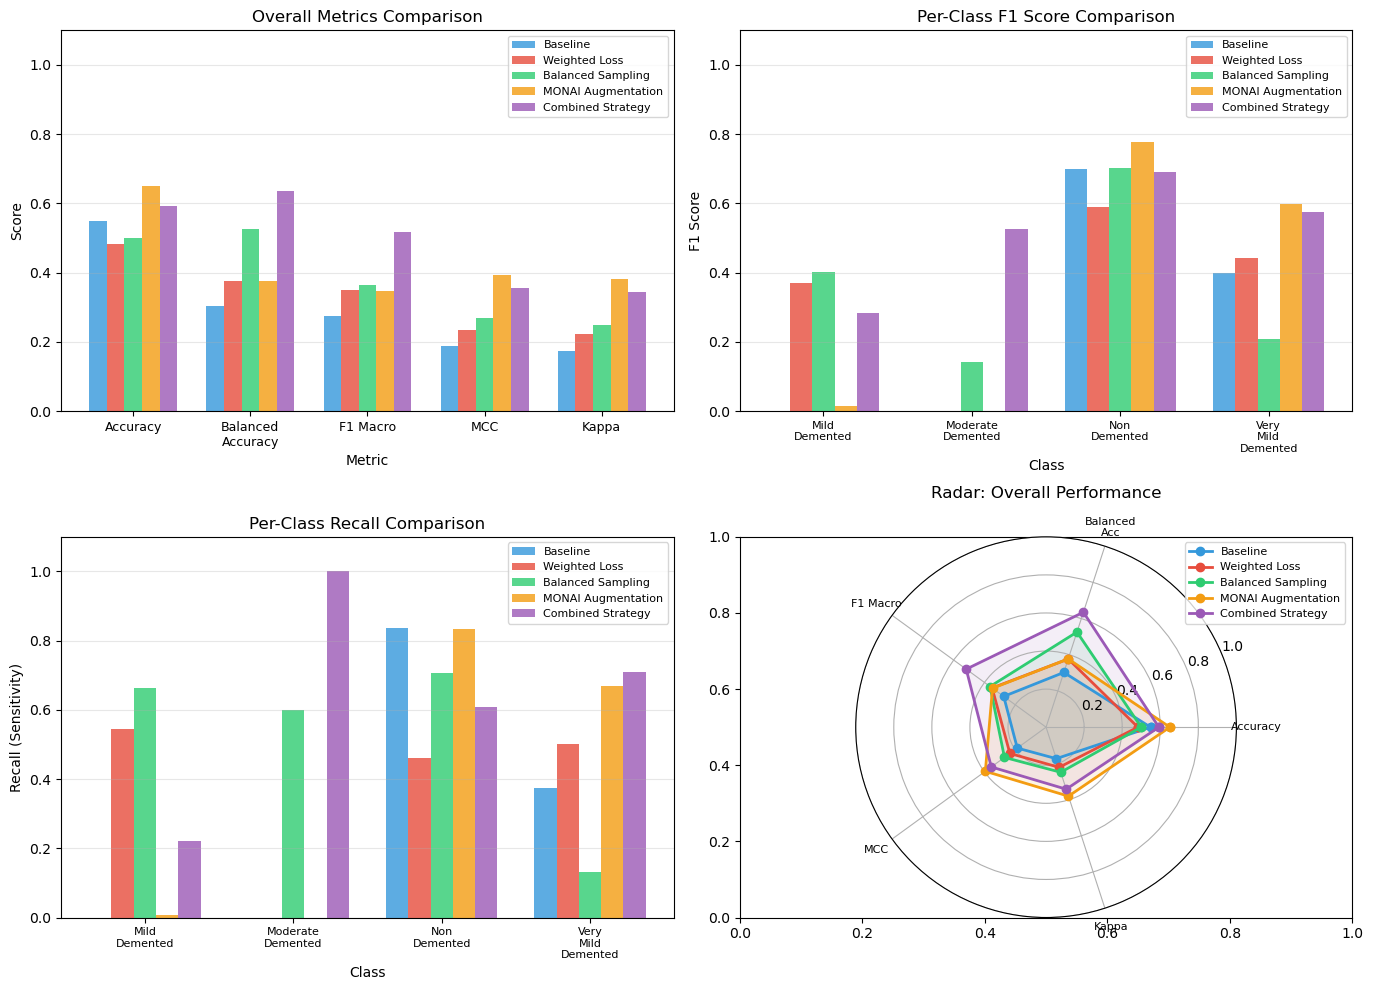


📊 Metrics visualization saved to 'comparison_metrics.png'


In [30]:
# ====== VISUALIZATION: METRICS COMPARISON ======

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Overall metrics comparison (bar chart)
ax1 = axes[0, 0]
metrics_to_plot = ['accuracy', 'balanced_accuracy', 'f1_macro', 'mcc', 'kappa']
x = np.arange(len(metrics_to_plot))
width = 0.15
approaches = list(all_results.keys())
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (approach, color) in enumerate(zip(approaches, colors)):
    values = [all_results[approach][m] for m in metrics_to_plot]
    ax1.bar(x + i*width, values, width, label=approach.split('. ')[1], color=color, alpha=0.8)

ax1.set_xlabel('Metric')
ax1.set_ylabel('Score')
ax1.set_title('Overall Metrics Comparison')
ax1.set_xticks(x + width*2)
ax1.set_xticklabels(['Accuracy', 'Balanced\nAccuracy', 'F1 Macro', 'MCC', 'Kappa'], fontsize=9)
ax1.legend(loc='upper right', fontsize=8)
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)

# 2. Per-class F1 comparison (grouped bar)
ax2 = axes[0, 1]
x = np.arange(len(class_names))
for i, (approach, color) in enumerate(zip(approaches, colors)):
    values = [all_results[approach]['per_class'][cls]['f1'] for cls in class_names]
    ax2.bar(x + i*width, values, width, label=approach.split('. ')[1], color=color, alpha=0.8)

ax2.set_xlabel('Class')
ax2.set_ylabel('F1 Score')
ax2.set_title('Per-Class F1 Score Comparison')
ax2.set_xticks(x + width*2)
ax2.set_xticklabels([c.replace(' ', '\n') for c in class_names], fontsize=8)
ax2.legend(loc='upper right', fontsize=8)
ax2.set_ylim(0, 1.1)
ax2.grid(axis='y', alpha=0.3)

# 3. Per-class Recall comparison (important for minority classes)
ax3 = axes[1, 0]
for i, (approach, color) in enumerate(zip(approaches, colors)):
    values = [all_results[approach]['per_class'][cls]['recall'] for cls in class_names]
    ax3.bar(x + i*width, values, width, label=approach.split('. ')[1], color=color, alpha=0.8)

ax3.set_xlabel('Class')
ax3.set_ylabel('Recall (Sensitivity)')
ax3.set_title('Per-Class Recall Comparison')
ax3.set_xticks(x + width*2)
ax3.set_xticklabels([c.replace(' ', '\n') for c in class_names], fontsize=8)
ax3.legend(loc='upper right', fontsize=8)
ax3.set_ylim(0, 1.1)
ax3.grid(axis='y', alpha=0.3)

# 4. Radar chart for overall metrics
ax4 = axes[1, 1]
metrics_radar = ['accuracy', 'balanced_accuracy', 'f1_macro', 'mcc', 'kappa']
angles = np.linspace(0, 2*np.pi, len(metrics_radar), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

ax4 = fig.add_subplot(224, polar=True)
for approach, color in zip(approaches, colors):
    values = [all_results[approach][m] for m in metrics_radar]
    values += values[:1]  # Complete the circle
    ax4.plot(angles, values, 'o-', linewidth=2, label=approach.split('. ')[1], color=color)
    ax4.fill(angles, values, alpha=0.1, color=color)

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(['Accuracy', 'Balanced\nAcc', 'F1 Macro', 'MCC', 'Kappa'], fontsize=8)
ax4.set_ylim(0, 1)
ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=8)
ax4.set_title('Radar: Overall Performance', y=1.08)

plt.tight_layout()
plt.savefig('comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Metrics visualization saved to 'comparison_metrics.png'")

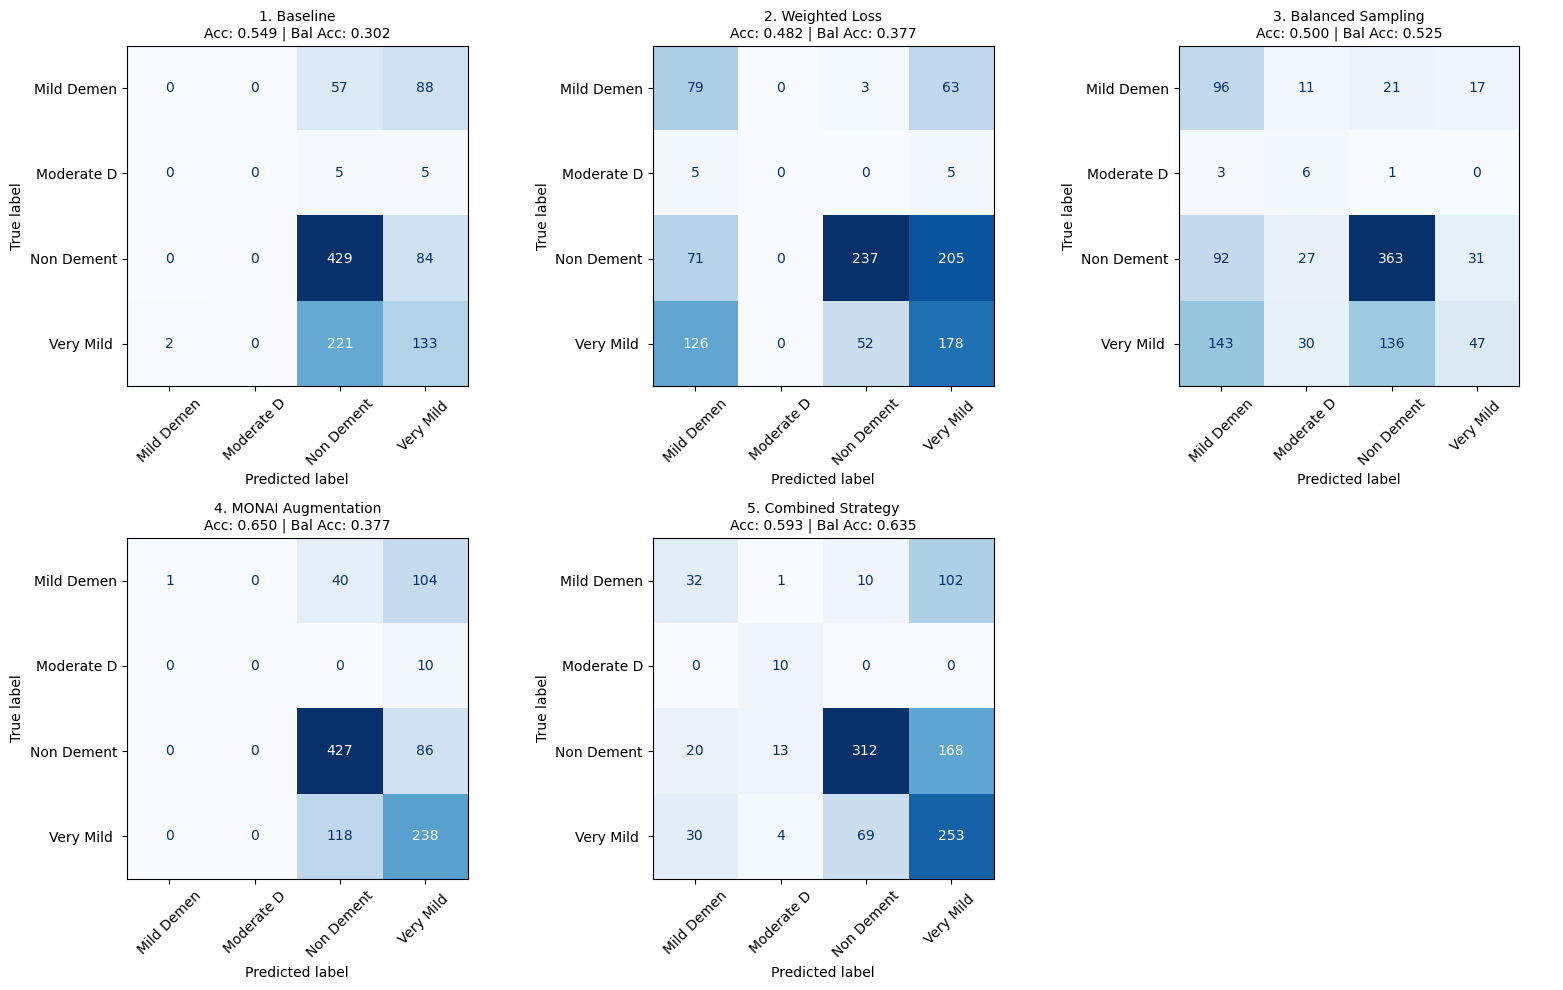


📊 Confusion matrices saved to 'confusion_matrices_comparison.png'


In [31]:
# ====== CONFUSION MATRICES COMPARISON ======

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

all_preds = {
    '1. Baseline': (preds_baseline, labels_baseline),
    '2. Weighted Loss': (preds_weighted, labels_weighted),
    '3. Balanced Sampling': (preds_balanced, labels_balanced),
    '4. MONAI Augmentation': (preds_monai, labels_monai),
    '5. Combined Strategy': (preds_combined, labels_combined),
}

for ax, (name, (preds, labels)) in zip(axes, all_preds.items()):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=[c[:10] for c in class_names])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nAcc: {all_results[name]["accuracy"]:.3f} | Bal Acc: {all_results[name]["balanced_accuracy"]:.3f}', fontsize=10)
    ax.tick_params(axis='x', rotation=45)

# Hide the empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Confusion matrices saved to 'confusion_matrices_comparison.png'")

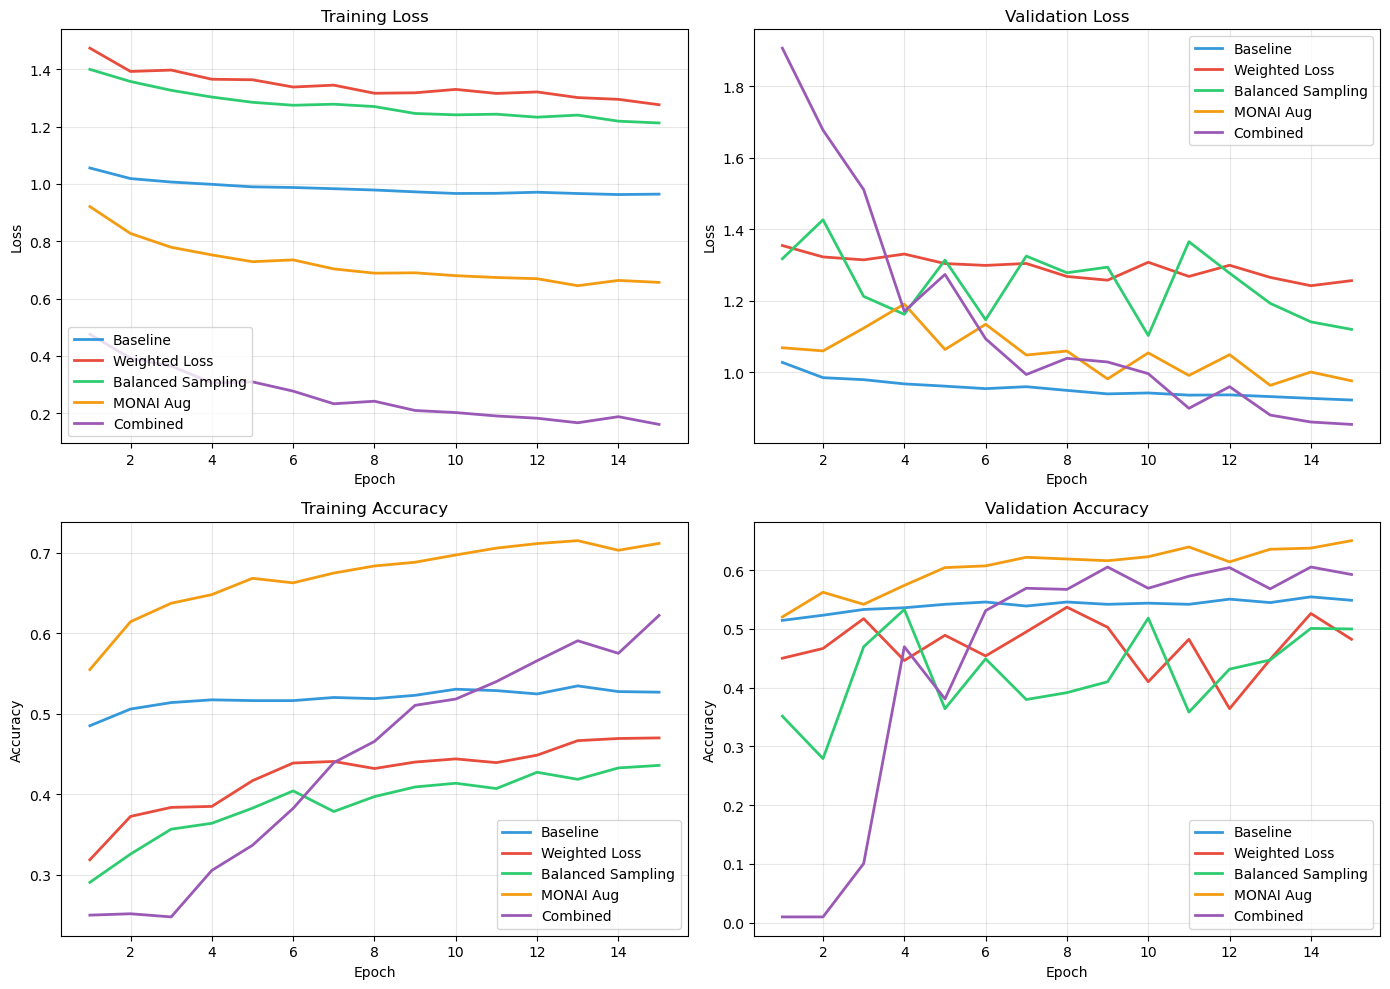


📊 Training curves saved to 'training_curves_comparison.png'


In [32]:
# ====== TRAINING CURVES COMPARISON ======

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

all_histories = {
    'Baseline': hist_baseline,
    'Weighted Loss': hist_weighted,
    'Balanced Sampling': hist_balanced,
    'MONAI Aug': hist_monai,
    'Combined': hist_combined,
}

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# Training Loss
ax1 = axes[0, 0]
for (name, hist), color in zip(all_histories.items(), colors):
    epochs = range(1, len(hist['train_loss']) + 1)
    ax1.plot(epochs, hist['train_loss'], '-', label=name, color=color, linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Validation Loss
ax2 = axes[0, 1]
for (name, hist), color in zip(all_histories.items(), colors):
    epochs = range(1, len(hist['val_loss']) + 1)
    ax2.plot(epochs, hist['val_loss'], '-', label=name, color=color, linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Validation Loss')
ax2.legend()
ax2.grid(alpha=0.3)

# Training Accuracy
ax3 = axes[1, 0]
for (name, hist), color in zip(all_histories.items(), colors):
    epochs = range(1, len(hist['train_acc']) + 1)
    ax3.plot(epochs, hist['train_acc'], '-', label=name, color=color, linewidth=2)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy')
ax3.set_title('Training Accuracy')
ax3.legend()
ax3.grid(alpha=0.3)

# Validation Accuracy
ax4 = axes[1, 1]
for (name, hist), color in zip(all_histories.items(), colors):
    epochs = range(1, len(hist['val_acc']) + 1)
    ax4.plot(epochs, hist['val_acc'], '-', label=name, color=color, linewidth=2)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Accuracy')
ax4.set_title('Validation Accuracy')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Training curves saved to 'training_curves_comparison.png'")

In [33]:
# ====== SUMMARY: BEST APPROACH ANALYSIS ======

print("=" * 80)
print("SUMMARY: COMPARATIVE ANALYSIS RESULTS")
print("=" * 80)

# Find best approach for each metric
best_for_metric = {}
metrics_of_interest = ['accuracy', 'balanced_accuracy', 'f1_macro', 'mcc', 'kappa']

for metric in metrics_of_interest:
    best_approach = max(all_results.keys(), key=lambda x: all_results[x][metric])
    best_value = all_results[best_approach][metric]
    best_for_metric[metric] = (best_approach, best_value)

print("\n🏆 BEST APPROACH FOR EACH METRIC:")
print("-" * 50)
for metric, (approach, value) in best_for_metric.items():
    print(f"  {metric:20s}: {approach:25s} ({value:.4f})")

# Improvement analysis over baseline
print("\n📈 IMPROVEMENT OVER BASELINE:")
print("-" * 50)
baseline_results = all_results['1. Baseline']
for approach in list(all_results.keys())[1:]:
    improvements = []
    for metric in metrics_of_interest:
        baseline_val = baseline_results[metric]
        new_val = all_results[approach][metric]
        improvement = ((new_val - baseline_val) / baseline_val) * 100 if baseline_val != 0 else 0
        improvements.append(improvement)
    avg_improvement = np.mean(improvements)
    print(f"  {approach}: Avg improvement = {avg_improvement:+.2f}%")

# Per-class analysis for minority class
print(f"\n🔍 MINORITY CLASS ANALYSIS ({LABELS[min_class]}):")
print("-" * 50)
for approach in all_results.keys():
    minority_recall = all_results[approach]['per_class'][LABELS[min_class]]['recall']
    minority_f1 = all_results[approach]['per_class'][LABELS[min_class]]['f1']
    print(f"  {approach}: Recall={minority_recall:.4f}, F1={minority_f1:.4f}")

# Overall recommendation
print("\n" + "=" * 80)
print("📋 RECOMMENDATIONS:")
print("=" * 80)

# Score each approach
approach_scores = {}
for approach in all_results.keys():
    score = 0
    # Weight balanced accuracy and F1 macro more for imbalanced data
    score += all_results[approach]['balanced_accuracy'] * 2
    score += all_results[approach]['f1_macro'] * 2
    score += all_results[approach]['mcc'] * 1.5
    score += all_results[approach]['accuracy']
    # Bonus for minority class performance
    score += all_results[approach]['per_class'][LABELS[min_class]]['recall'] * 1.5
    approach_scores[approach] = score

ranked = sorted(approach_scores.items(), key=lambda x: x[1], reverse=True)
print("\n🥇 Ranked by weighted composite score (prioritizing balanced metrics):")
for i, (approach, score) in enumerate(ranked, 1):
    medal = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
    print(f"  {medal} {i}. {approach} (score: {score:.4f})")

SUMMARY: COMPARATIVE ANALYSIS RESULTS

🏆 BEST APPROACH FOR EACH METRIC:
--------------------------------------------------
  accuracy            : 4. MONAI Augmentation     (0.6504)
  balanced_accuracy   : 5. Combined Strategy      (0.6349)
  f1_macro            : 5. Combined Strategy      (0.5185)
  mcc                 : 4. MONAI Augmentation     (0.3943)
  kappa               : 4. MONAI Augmentation     (0.3812)

📈 IMPROVEMENT OVER BASELINE:
--------------------------------------------------
  2. Weighted Loss: Avg improvement = +18.62%
  3. Balanced Sampling: Avg improvement = +36.98%
  4. MONAI Augmentation: Avg improvement = +59.96%
  5. Combined Strategy: Avg improvement = +78.78%

🔍 MINORITY CLASS ANALYSIS (Moderate Demented):
--------------------------------------------------
  1. Baseline: Recall=0.0000, F1=0.0000
  2. Weighted Loss: Recall=0.0000, F1=0.0000
  3. Balanced Sampling: Recall=0.6000, F1=0.1429
  4. MONAI Augmentation: Recall=0.0000, F1=0.0000
  5. Combined Strateg

In [34]:
# ====== EXPORT RESULTS TO CSV ======

# Create comprehensive results DataFrame
results_data = []
for approach, metrics in all_results.items():
    row = {
        'Approach': approach,
        'Accuracy': metrics['accuracy'],
        'Balanced Accuracy': metrics['balanced_accuracy'],
        'Specificity Macro': metrics['specificity_macro'],
        'F1 Macro': metrics['f1_macro'],
        'F1 Weighted': metrics['f1_weighted'],
        'MCC': metrics['mcc'],
        'Kappa': metrics['kappa'],
        'ROC-AUC OvR Macro': metrics.get('roc_auc_ovr'),
    }
    for cls in class_names:
        row[f'{cls}_Precision'] = metrics['per_class'][cls]['precision']
        row[f'{cls}_Recall'] = metrics['per_class'][cls]['recall']
        row[f'{cls}_Specificity'] = metrics['per_class'][cls]['specificity']
        row[f'{cls}_F1'] = metrics['per_class'][cls]['f1']
        row[f'{cls}_Support'] = metrics['per_class'][cls]['support']
    results_data.append(row)

results_df = pd.DataFrame(results_data)
results_df.to_csv('comparison_results.csv', index=False)
print("📄 Full results exported to 'comparison_results.csv'")

# Display summary table
display_cols = [
    'Approach', 'Accuracy', 'Balanced Accuracy', 'Specificity Macro',
    'F1 Macro', 'MCC', 'Kappa', 'ROC-AUC OvR Macro'
]
print()
print(results_df[display_cols].round(4).to_string(index=False))


📄 Full results exported to 'comparison_results.csv'

             Approach  Accuracy  Balanced Accuracy  F1 Macro      MCC    Kappa
          1. Baseline  0.548828           0.302463  0.274952 0.186848 0.173891
     2. Weighted Loss  0.482422           0.376704  0.350213 0.234878 0.221883
 3. Balanced Sampling  0.500000           0.525423  0.363561 0.270109 0.249208
4. MONAI Augmentation  0.650391           0.376949  0.347743 0.394262 0.381173
 5. Combined Strategy  0.592773           0.634888  0.518543 0.355636 0.342696
